In [287]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import re

In [236]:
df = pd.read_csv("AllRuns_cleaned.csv")
print(df.columns.values)

if (df.isnull().any().any()): print('\nData is clean.')

['Timestamp' '_rx_time' 'SOC_Ah' 'Pack_Voltage' 'Pack_Current'
 'Bus_Voltage' 'Bus_Current' 'Motor_Velocity' 'Vehicle_Velocity'
 'PhaseC_Current' 'PhaseB_Current' 'Input_Voltage_A' 'Input_Current_A'
 'Output_Voltage_A' 'Output_Current_A' 'Input_Voltage_B' 'Input_Current_B'
 'Output_Voltage_B' 'Output_Current_B' 'Input_Voltage_C' 'Input_Current_C'
 'Output_Voltage_C' 'Output_Current_C' 'Input_Voltage_D' 'Input_Current_D'
 'Output_Voltage_D' 'Output_Current_D' 'Latitude' 'Longitude' 'Altitude'
 'Speed' 'acc_X' 'acc_Y' 'acc_Z' 'Throttle_Perc' 'Brake_Status'
 'Precharge_Contactor_Flag1' 'Precharge_Contactor_Flag2'
 'Precharge_Contactor_Flag3' 'Precharge_Contactor_Flag4'
 'Precharge_Contactor_Flag5' 'Precharge_Contactor_Flag6'
 'Precharge_Contactor_Flag7' 'Precharge_Contactor_Flag8'
 'Precharge_State_Flag1' 'Precharge_State_Flag2' 'Precharge_State_Flag3'
 'Precharge_State_Flag4' 'Precharge_State_Flag5' 'BMS_Flag1' 'BMS_Flag2'
 'BMS_Flag3' 'BMS_Flag4' 'BMS_Flag5' 'BMS_Flag6' 'BMS_Flag7' 'BMS

In [288]:
drop_columns = []

for i in df.columns.values: 
    match = re.search(r'^CMU|Timestamp|Flag\d+|.*Current.*|.*Voltage.*|^Controller|^Mosfet|^Cabin|^Cell|Temp$|itude$|^acc|Speed|error|Brake_Status',i)
    if match: drop_columns.append(i)

df = df.drop(columns=drop_columns)
df['_time_sec'] = pd.to_numeric(df['_time_sec'], errors='coerce')
df = df.dropna(subset=['_time_sec']).reset_index(drop=True)

print(df.columns.values)

['_rx_time' 'SOC_Ah' 'Motor_Velocity' 'Vehicle_Velocity' 'Throttle_Perc'
 '_time_sec' '_time_str' 'Power_consumed' 'Total_Input_Power'
 'Output_Power' 'Battery_Level_Pct' 'Time_diff' 'Acceleration' 'Gradient'
 'dy' 'Lap_Ends' 'Lap']


In [289]:
print(df.head(1))

                           _rx_time   SOC_Ah  Motor_Velocity  \
0  2026-05-03 09:53:21.431907+05:30  14.6032        196.1315   

   Vehicle_Velocity  Throttle_Perc     _time_sec _time_str  Power_consumed  \
0          20.33352          0.857  35601.431907  09:53:21     2945.795347   

   Total_Input_Power  Output_Power  Battery_Level_Pct  Time_diff  \
0         855.434757   2945.795347       54500.767633        NaN   

   Acceleration  Gradient  dy  Lap_Ends  Lap  
0           NaN       NaN NaN       NaN    1  


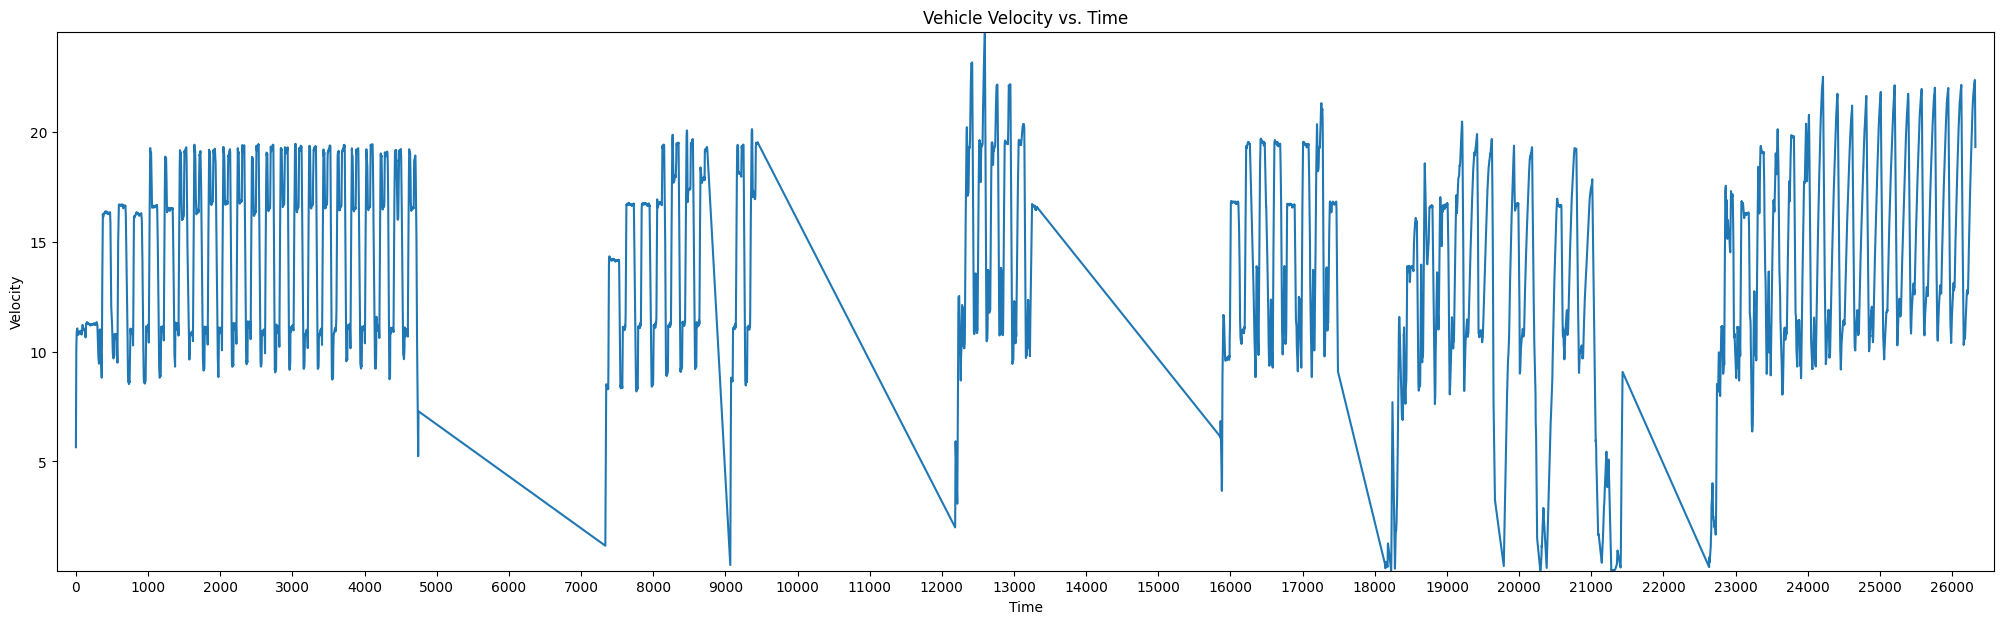

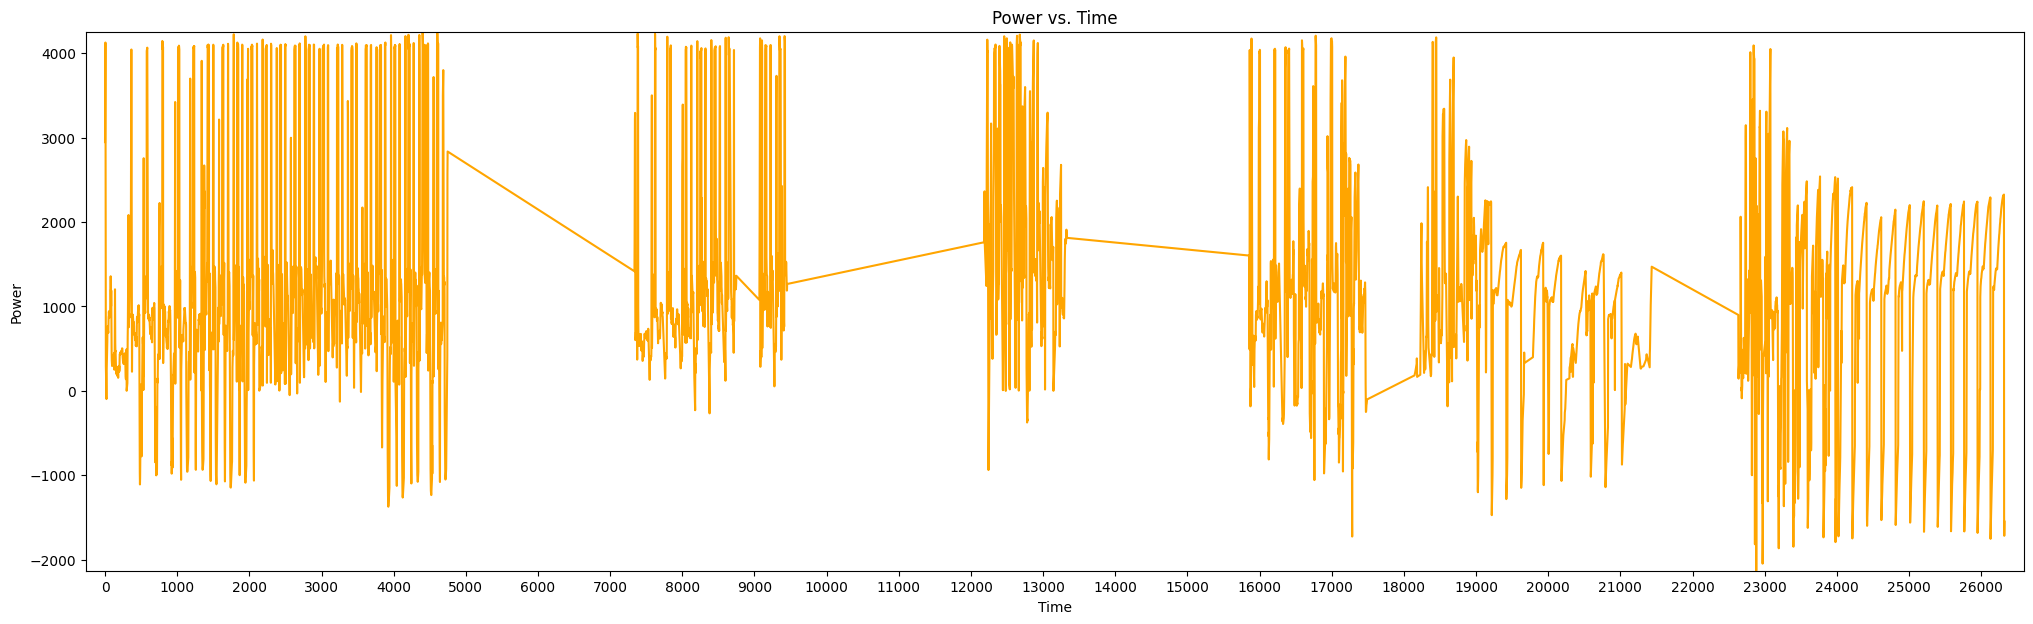

In [290]:
x = df['_time_sec'] - df['_time_sec'][0]

plt.figure(figsize=(25,7))
plt.title('Vehicle Velocity vs. Time')
plt.xlabel('Time')
plt.ylabel('Velocity')
plt.xticks([1000*i for i in range(0,30)])
plt.margins(x=10e-3, y=0)
plt.plot(x,df['Vehicle_Velocity']/3.6)
plt.show()

plt.figure(figsize=(25,7))
plt.title('Power vs. Time')
plt.xlabel('Time')
plt.ylabel('Power')
plt.xticks([1000*i for i in range(0,30)])
plt.margins(x=10e-3, y=0)
plt.plot(x,df['Power_consumed'],color='orange')
plt.show()

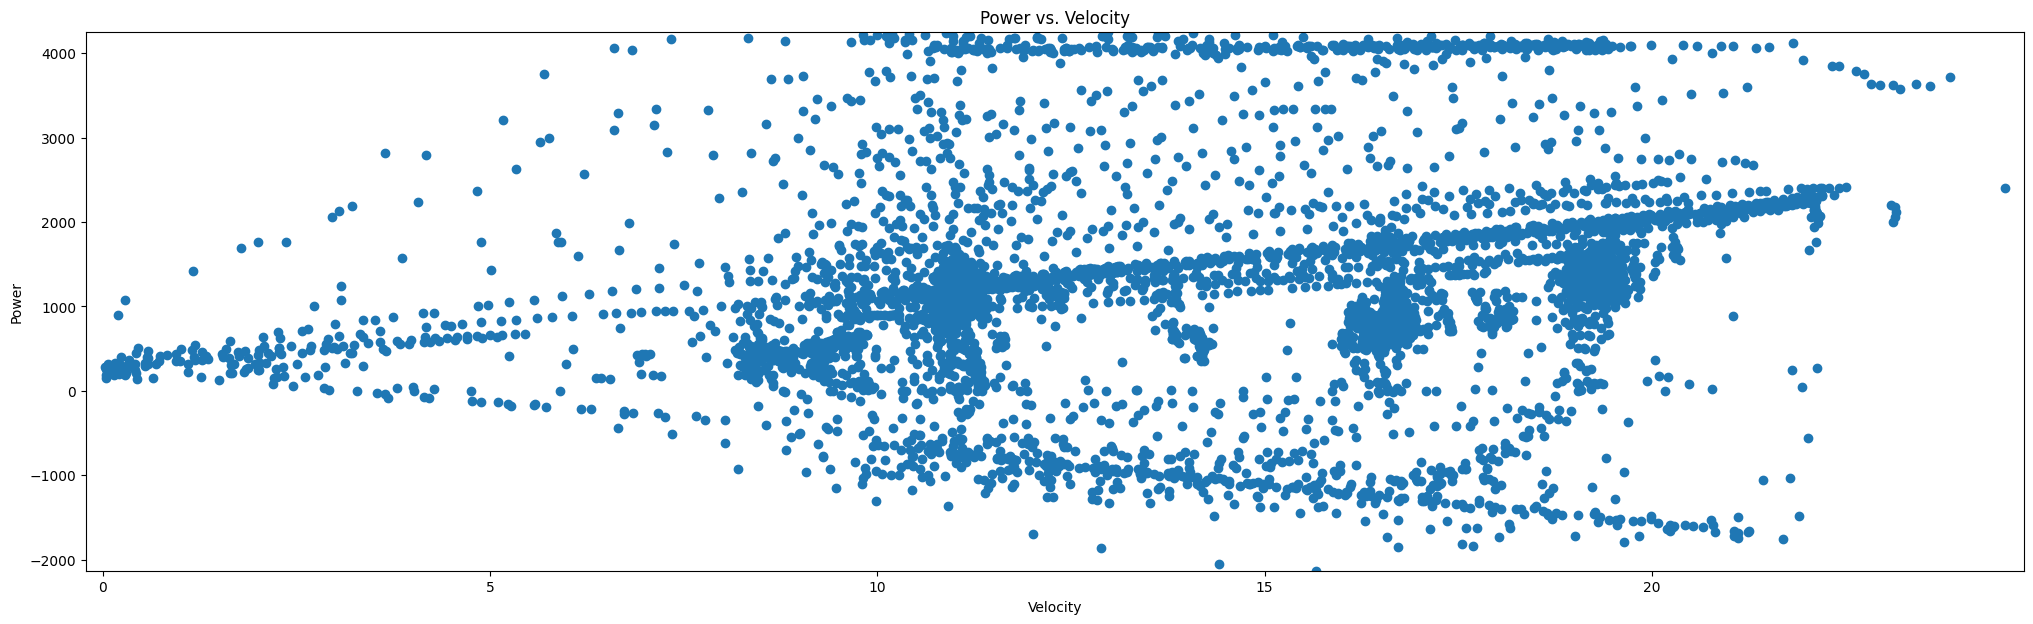

In [291]:
plt.figure(figsize=(25,7))
plt.title('Power vs. Velocity')
plt.xlabel('Velocity')
plt.ylabel('Power')
plt.xticks([5*i for i in range(0,21)])
plt.margins(x=10e-3, y=0)
plt.scatter(df['Vehicle_Velocity']/3.6,df['Power_consumed'])
plt.show()

In [242]:
(df.loc[df['_time_sec']-df['_time_sec'][0]<=7000])[['_rx_time','Vehicle_Velocity','Acceleration']].tail(50)

,_rx_time,Vehicle_Velocity,Acceleration
1724,2026-05-03 11:10:09.319505+05:30,54.38520,1.692833
1725,2026-05-03 11:10:12.739478+05:30,60.62544,1.824646
1726,2026-05-03 11:10:14.925275+05:30,63.49752,1.313974
1727,2026-05-03 11:10:17.108668+05:30,66.21228,1.243368
1728,2026-05-03 11:10:19.294033+05:30,68.62932,1.106012
1729,2026-05-03 11:10:20.730088+05:30,69.14916,0.361992
1730,2026-05-03 11:10:22.754149+05:30,68.59080,-0.275861
1731,2026-05-03 11:10:24.960891+05:30,68.52096,-0.031648
1732,2026-05-03 11:10:32.754110+05:30,68.66964,0.019078
1733,2026-05-03 11:10:37.139266+05:30,66.29076,-0.620207


In [243]:
print('*'*20)
print()
print('        ZOOM')
print()
print('*'*20)

********************

        ZOOM

********************


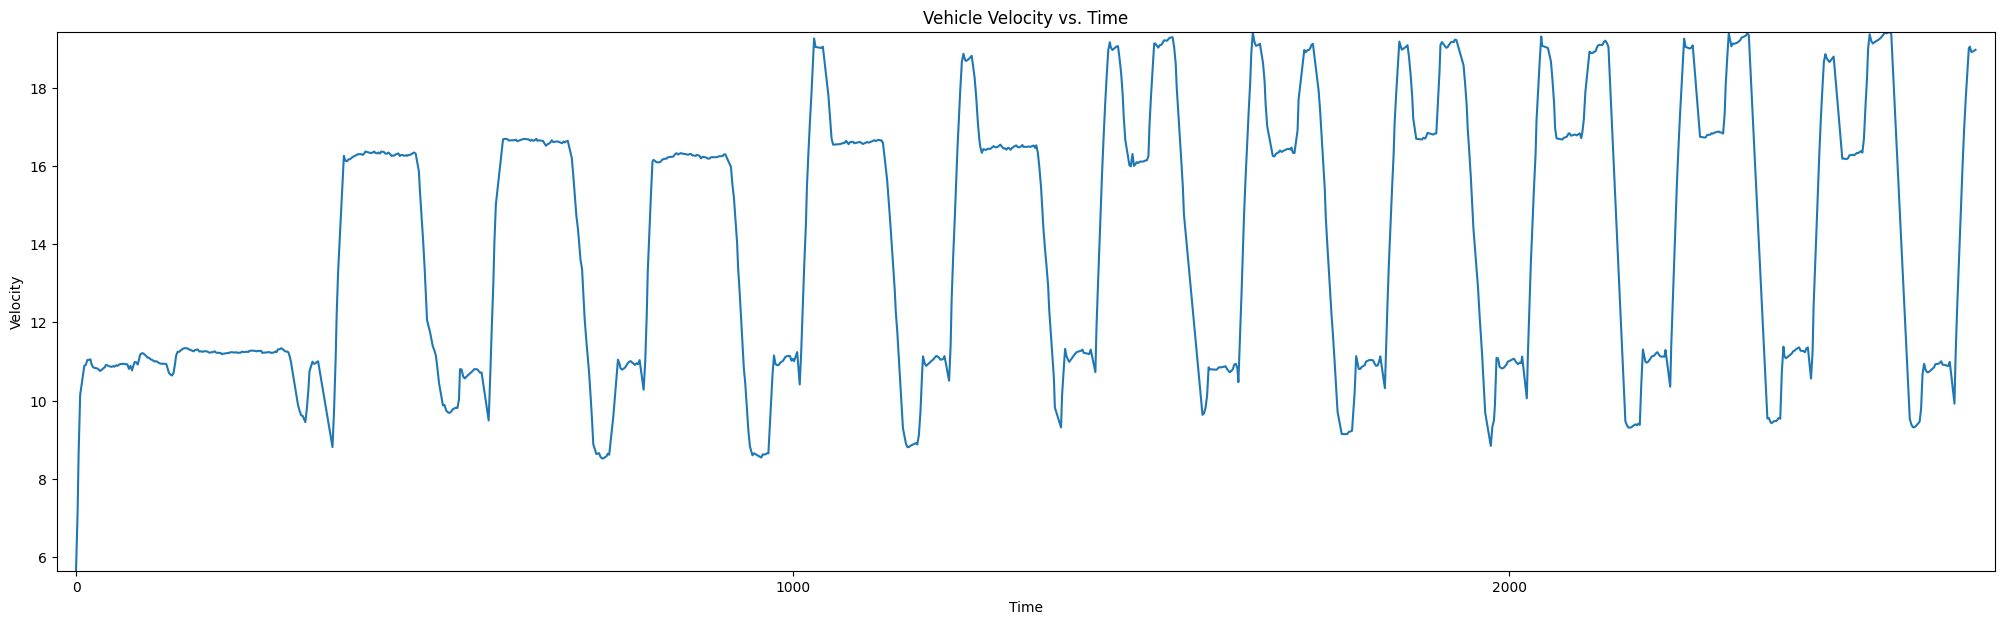

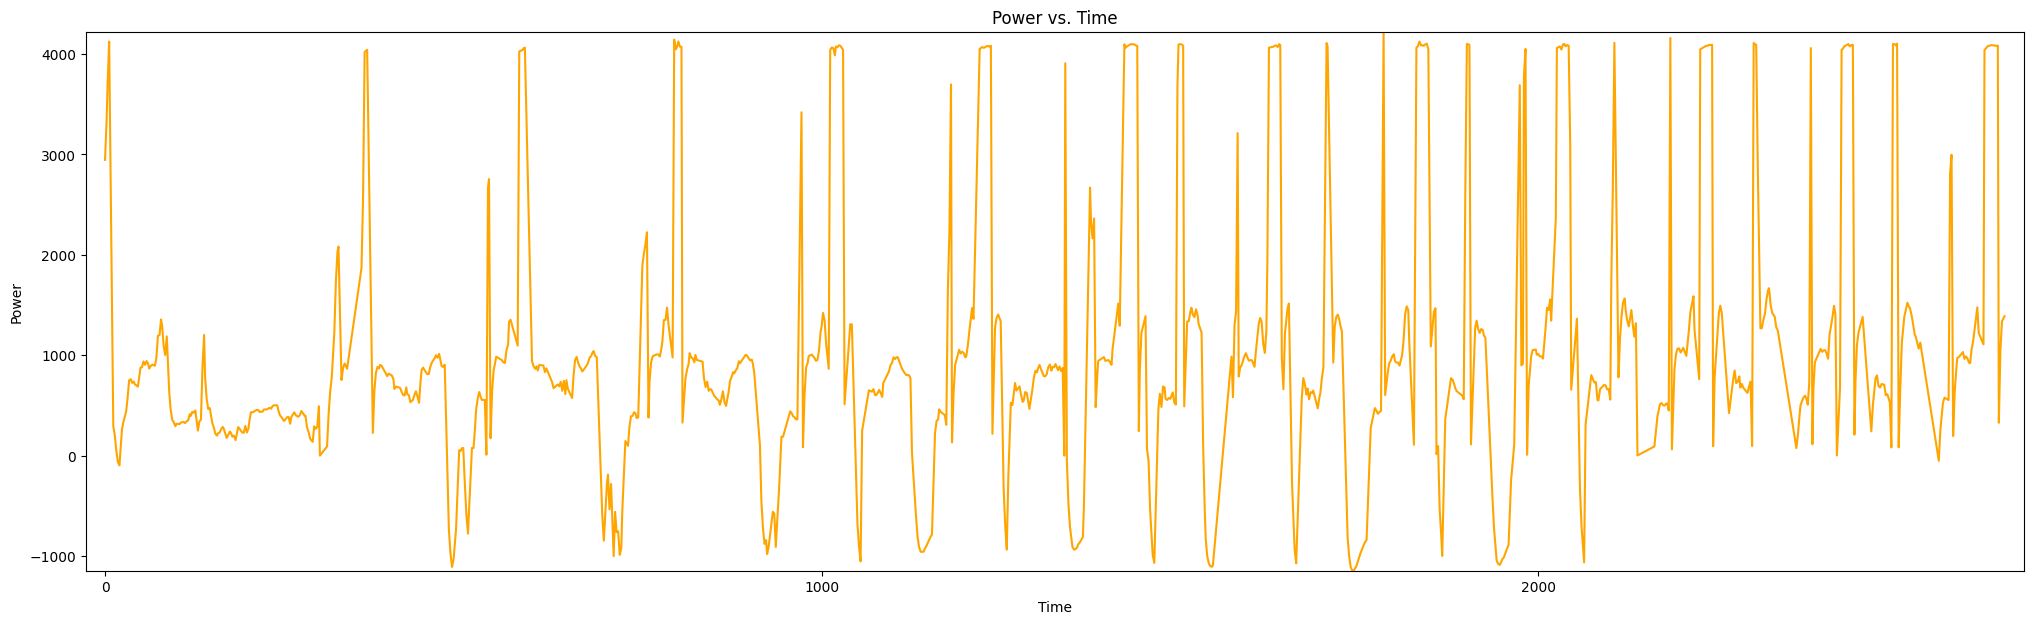

In [244]:
x = df['_time_sec'] - df['_time_sec'][0]

plt.figure(figsize=(25,7))
plt.title('Vehicle Velocity vs. Time')
plt.xlabel('Time')
plt.ylabel('Velocity')
plt.xticks([1000*i for i in range(0,30)])
plt.margins(x=10e-3, y=0)
plt.plot(x[:1000],(df['Vehicle_Velocity']/3.6)[:1000])
plt.show()

plt.figure(figsize=(25,7))
plt.title('Power vs. Time')
plt.xlabel('Time')
plt.ylabel('Power')
plt.xticks([1000*i for i in range(0,30)])
plt.margins(x=10e-3, y=0)
plt.plot(x[:1000],df['Power_consumed'][:1000],color='orange')
plt.show()

In [314]:
dt = df['_time_sec'].diff().fillna(0.0).clip(lower=0).values

jerk = df['Acceleration'].diff().fillna(0.0).values
 
JERK_THRESH = 1e-1   
MIN_INTERP_LEN = 30 
 
jerk_zero = np.abs(jerk) < JERK_THRESH

car_off = np.zeros(len(df), dtype=bool)
i = 0
while i < len(jerk_zero):
    if jerk_zero[i]:
        j = i
        while j < len(jerk_zero) and jerk_zero[j]:
            j += 1
        if (j-i) >= MIN_INTERP_LEN:
            car_off[i:j] = True
        i = j
    else:
        i += 1
 
df['Car_Off'] = car_off
n_off = car_off.sum()
print(f"Car-off rows masked: {n_off} ({100*n_off/len(df):.1f}%)")

Car-off rows masked: 36 (0.6%)


In [320]:
eta_motor = 0.95
m = 310
g = 9.81
k = 0.098
crr = 0.007
output_power = df['Output_Power']
v = df['Vehicle_Velocity']/3.6
a = df['Acceleration']/3.6

A = m*g*v
B = crr*m*g*v
C = ((output_power-50)*eta_motor) - (k*(v**3)+(m*a*v))

phi = np.arctan2(B,A)
ratio = np.clip(C / np.sqrt(A**2 + B**2), -1.0, 1.0)
df['Gradient'] = np.arcsin(ratio) - phi

df.loc[df['Car_Off'], 'Gradient'] = np.nan

SMOOTH_WIN = 11
df['Gradient_smooth'] = (df['Gradient'].rolling(SMOOTH_WIN, center=True, min_periods=1).median())

df['Gradient_smooth'][:1000].tail(20)

980    0.015762
981    0.015762
982    0.015795
983    0.017161
984    0.019928
985    0.020695
986    0.020695
987    0.020695
988    0.020695
989    0.019928
990    0.019547
991    0.018348
992    0.018348
993    0.017818
994    0.014882
995    0.013944
996    0.004340
997    0.003293
998    0.002265
999    0.002019
Name: Gradient_smooth, dtype: float64

In [326]:
v_active = df['Vehicle_Velocity'].copy()
v_active[car_off] = 0.0   # suppress car-off regions
 
# Estimate sampling rate
median_dt = np.median(dt[dt > 0])
fs = 1.0 / median_dt                     # samples/s
print(f"Sampling rate: {fs:.2f} Hz")
 
MIN_LAP_TIME_S  = 60     # seconds — adjust to your track
MIN_LAP_SAMPLES = int(MIN_LAP_TIME_S * fs)
 
VALLEY_PROMINENCE_KMH = 8    # km/h — the start/finish dip is typically much deeper
 
valleys, _ = find_peaks(
    -v_active.values,
    distance   = MIN_LAP_SAMPLES,
    prominence = VALLEY_PROMINENCE_KMH,
)
print(f"Valleys (lap boundaries) found: {len(valleys)}")
 
lap_boundaries = [0] + [int(v) for v in valleys] + [len(df) - 1]
lap_boundaries = sorted(set(lap_boundaries))
 
# Assign lap numbers (car-off rows get Lap=0 → excluded later)
df['Lap'] = 0
for lap_num, (start, end) in enumerate(
        zip(lap_boundaries[:-1], lap_boundaries[1:]), start=1):
    df.iloc[start:end, df.columns.get_loc('Lap')] = lap_num
 
num_laps = df['Lap'].max()
print(f"Laps segmented: {num_laps}")

Sampling rate: 0.46 Hz
Valleys (lap boundaries) found: 98
Laps segmented: 99


In [327]:
dt_series = df['_time_sec'].diff().fillna(0.0).clip(lower=0)
 
# Determine bin size from median lap distance
lap_distances = []
for lap_num in range(1, num_laps + 1):
    mask = (df['Lap'] == lap_num) 
    if mask.sum() < 10:
        continue
    ds = (v[mask] * dt_series[mask]).sum()
    lap_distances.append(ds)
 
median_lap_dist = np.median(lap_distances)
N_BINS = 200    
bin_size = median_lap_dist / N_BINS
bin_edges = np.arange(0, median_lap_dist + bin_size, bin_size)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
 
print(f"Median lap distance: {median_lap_dist:.1f} m  |  bin size: {bin_size:.2f} m")
 

all_lap_profiles = []    
 
for lap_num in range(1, num_laps + 1):
    mask = (df['Lap'] == lap_num) 
    sub  = df.loc[mask]
    if len(sub) < 10:
        continue
 
    v_lap = v.loc[mask].values
    grad_lap = df['Gradient_smooth'].loc[mask].values
    dt_lap = dt_series.loc[mask].values
 
    cum_dist = np.cumsum(v_lap * dt_lap)   # distance within lap
 
    # Only keep up to median_lap_dist (avoids over/under-length outlier laps
    # polluting the average)
    valid = np.isfinite(grad_lap) & (cum_dist <= median_lap_dist * 1.15)
 
    if valid.sum() < 10:
        continue
 
    bin_means = np.full(N_BINS, np.nan)
    for b in range(N_BINS):
        in_bin = valid & (cum_dist >= bin_edges[b]) & (cum_dist < bin_edges[b+1])
        if in_bin.sum() > 0:
            bin_means[b] = np.nanmean(grad_lap[in_bin])
 
    all_lap_profiles.append(bin_means)
 
profile_matrix = np.vstack(all_lap_profiles)          
avg_gradient = np.nanmean(profile_matrix, axis=0)   
std_gradient = np.nanstd(profile_matrix,  axis=0)

Median lap distance: 2584.2 m  |  bin size: 12.92 m


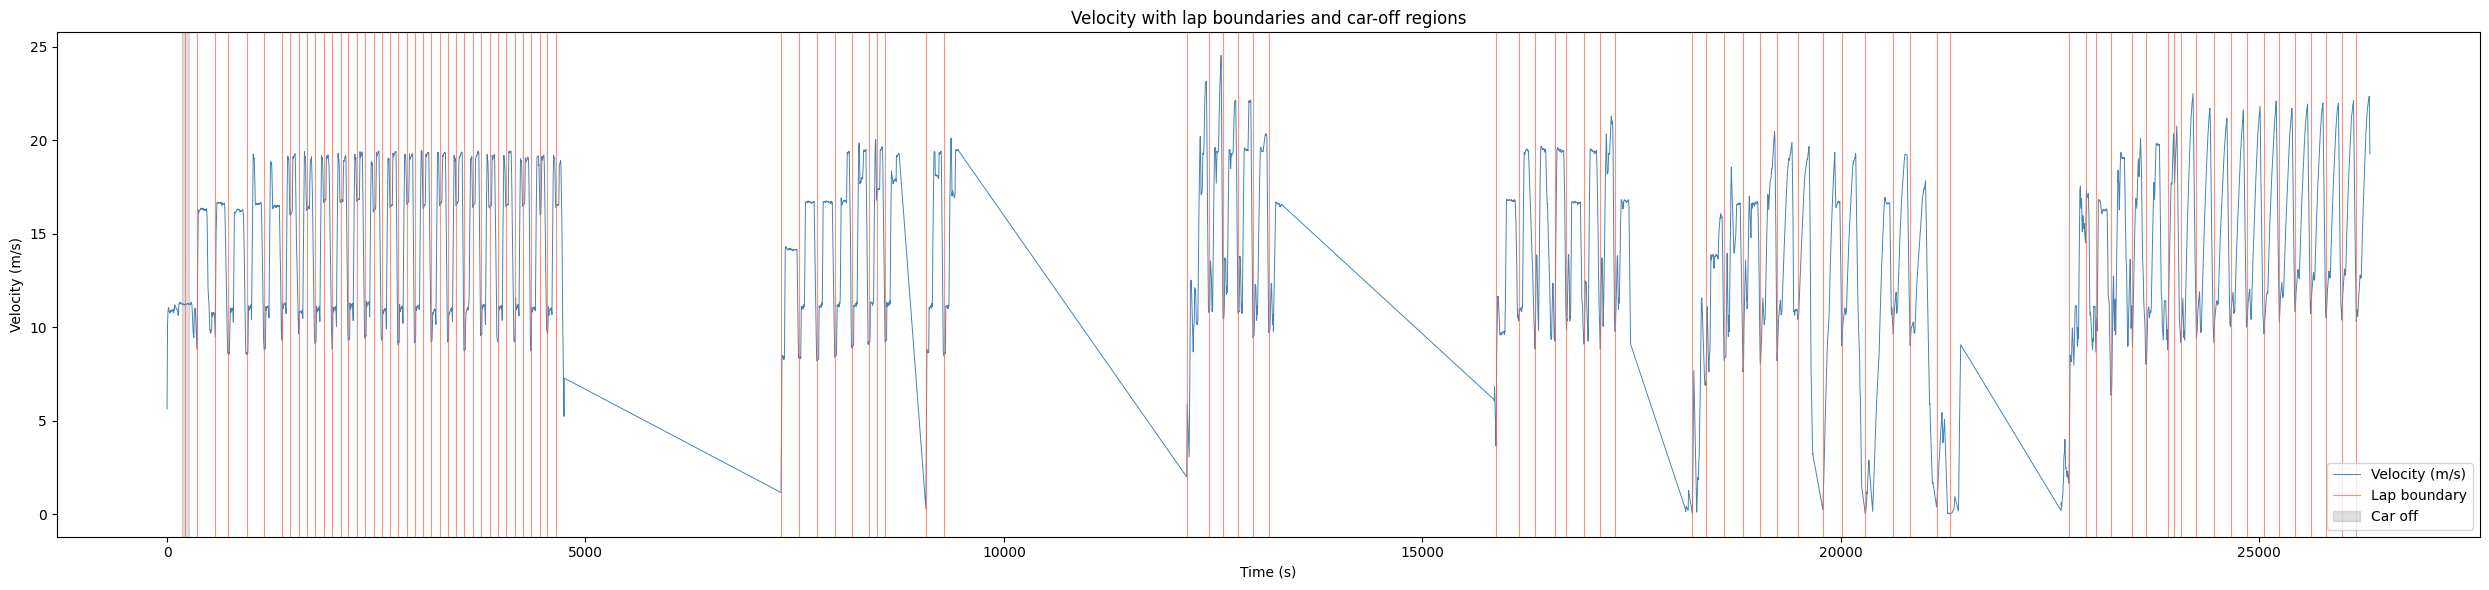

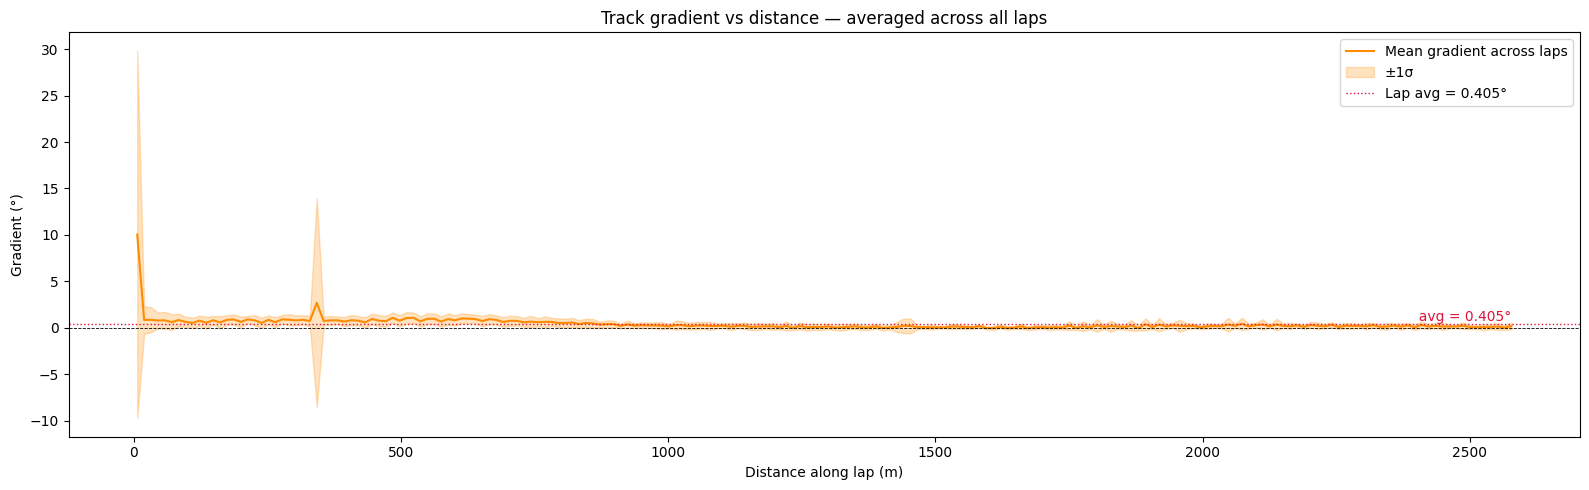

In [328]:
t_rel = df['_time_sec'] - df['_time_sec'].iloc[0]
 
fig, ax = plt.subplots(figsize=(25, 6))
ax.plot(t_rel, v, lw=0.7, color='steelblue', label='Velocity (m/s)')
for i, b in enumerate(lap_boundaries[1:-1]):
    ax.axvline(t_rel.iloc[b], color='tomato', lw=0.8, alpha=0.7,
               label='Lap boundary' if i == 0 else '')

in_off = False
for idx in range(len(df)):
    if car_off[idx] and not in_off:
        x0 = t_rel.iloc[idx]; in_off = True
    elif not car_off[idx] and in_off:
        ax.axvspan(x0, t_rel.iloc[idx], color='gray', alpha=0.25,
                   label='Car off' if 'Car off' not in [l.get_label() for l in ax.lines] else '')
        in_off = False
        
ax.set_xlabel('Time (s)'); ax.set_ylabel('Velocity (m/s)')
ax.set_title('Velocity with lap boundaries and car-off regions')
ax.legend(); plt.tight_layout(); plt.show()
 

overall_avg_deg = float(np.nanmean(np.degrees(avg_gradient)))
 
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(bin_centers, np.degrees(avg_gradient), color='darkorange', lw=1.5,
        label='Mean gradient across laps')
ax.fill_between(
    bin_centers,
    np.degrees(avg_gradient - std_gradient),
    np.degrees(avg_gradient + std_gradient),
    alpha=0.25, color='darkorange', label='±1σ'
)
ax.axhline(0, color='k', lw=0.6, ls='--')
ax.axhline(overall_avg_deg, color='crimson', lw=1.0, ls=':',
           label=f'Lap avg = {overall_avg_deg:.3f}°')
ax.text(
    bin_centers[-1], overall_avg_deg,
    f'  avg = {overall_avg_deg:.3f}°',
    color='crimson', va='bottom', ha='right', fontsize=10
)
ax.set_xlabel('Distance along lap (m)')
ax.set_ylabel('Gradient (°)')
ax.set_title('Track gradient vs distance — averaged across all laps')
ax.legend(); plt.tight_layout(); plt.show()
 